<a href="https://colab.research.google.com/github/sarika-845/RNN_NLP_Project/blob/main/RNN_NLP_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AG News dataset  was used to classify news articles into four categories: World, Sports, Business, and Sci/Tech.
# The challenge: build a deep learning model (RNN) that can learn sequential text patterns and achieve high accuracy on unseen data.

In [ ]:
# Import Libraries
import re
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [ ]:
from datasets import load_dataset
import pandas as pd

# Load AG News dataset (correct namespace)
dataset = load_dataset("fancyzhx/ag_news")

# Train/Test split
train_data = dataset['train']
test_data = dataset['test']

# Convert Hugging Face Dataset objects to Pandas DataFrames
train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

# Preview
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print(train_df.head())



README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Train shape: (120000, 2)
Test shape: (7600, 2)
                                                text  label
0  Wall St. Bears Claw Back Into the Black (Reute...      2
1  Carlyle Looks Toward Commercial Aerospace (Reu...      2
2  Oil and Economy Cloud Stocks' Outlook (Reuters...      2
3  Iraq Halts Oil Exports from Main Southern Pipe...      2
4  Oil prices soar to all-time record, posing new...      2


In [ ]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (120000, 2)
Test shape: (7600, 2)


In [ ]:
# 3. Clean Data

def clean_text(text):
    text = str(text).lower()                     # lowercase
    text = re.sub(r"[^a-z]", " ", text)          # keep only letters
    text = re.sub(r"\s+", " ", text).strip()     # collapse whitespace
    return text

train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)

# Preview cleaned text
print(train_df[['text', 'clean_text']].head())



                                                text  \
0  Wall St. Bears Claw Back Into the Black (Reute...   
1  Carlyle Looks Toward Commercial Aerospace (Reu...   
2  Oil and Economy Cloud Stocks' Outlook (Reuters...   
3  Iraq Halts Oil Exports from Main Southern Pipe...   
4  Oil prices soar to all-time record, posing new...   

                                          clean_text  
0  wall st bears claw back into the black reuters...  
1  carlyle looks toward commercial aerospace reut...  
2  oil and economy cloud stocks outlook reuters r...  
3  iraq halts oil exports from main southern pipe...  
4  oil prices soar to all time record posing new ...  


In [ ]:
# 5. Tokenization + Padding

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Initialize tokenizer
tokenizer = Tokenizer(num_words=20000, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['clean_text'])

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(train_df['clean_text'])
X_test_seq = tokenizer.texts_to_sequences(test_df['clean_text'])

# Pad sequences to fixed length
X_train_pad = pad_sequences(X_train_seq, maxlen=200, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=200, padding="post", truncating="post")

# Convert labels to arrays
y_train_arr = train_df['label'].values
y_test_arr = test_df['label'].values

print("Train padded shape:", X_train_pad.shape)
print("Test padded shape:", X_test_pad.shape)


Train padded shape: (120000, 200)
Test padded shape: (7600, 200)


In [ ]:
# 6. Build Simple RNN Model


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Define RNN model
rnn_model = Sequential([
    Embedding(input_dim=20000, output_dim=64, mask_zero=True),
    SimpleRNN(64),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(4, activation="softmax")   # 4 categories in AG News
])

# Compile model
rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

# Train model
history_rnn = rnn_model.fit(
    X_train_pad,       # must come from Step 5
    y_train_arr,       # must come from Step 5
    validation_split=0.1,
    epochs=15,
    batch_size=256,
    callbacks=[early_stop]
)




Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 97s 223ms/step - accuracy: 0.7969 - loss: 0.5461 - val_accuracy: 0.8865 - val_loss: 0.3235
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 93s 220ms/step - accuracy: 0.9161 - loss: 0.2739 - val_accuracy: 0.8873 - val_loss: 0.3273
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 92s 218ms/step - accuracy: 0.9310 - loss: 0.2284 - val_accuracy: 0.8839 - val_loss: 0.3358
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 92s 218ms/step - accuracy: 0.9414 - loss: 0.1966 - val_accuracy: 0.8721 - val_loss: 0.3749
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 144s 222ms/step - accuracy: 0.9467 - loss: 0.1760 - val_accuracy: 0.8733 - val_loss: 0.3860


238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step
Classification Report:

              precision    recall  f1-score   support

       World       0.92      0.89      0.90      1900
      Sports       0.94      0.96      0.95      1900
    Business       0.85      0.86      0.86      1900
    Sci/Tech       0.87      0.87      0.87      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600

Overall Accuracy: 0.8957894736842106


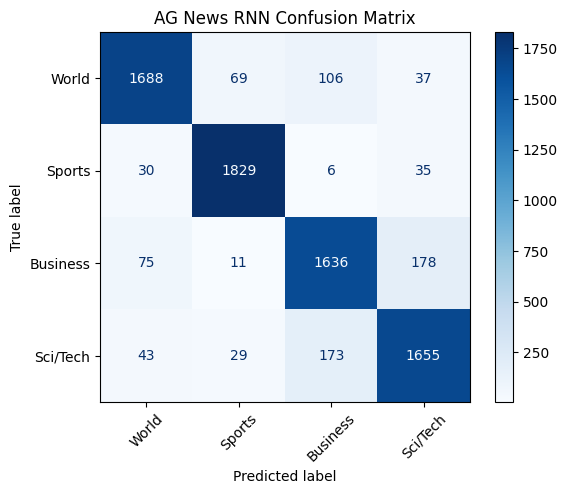

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict class indices (0–3)
y_pred = np.argmax(rnn_model.predict(X_test_pad), axis=1)

# Print classification report
print("Classification Report:\n")
print(classification_report(y_test_arr, y_pred, target_names=["World", "Sports", "Business", "Sci/Tech"]))

# Print overall accuracy
print("Overall Accuracy:", accuracy_score(y_test_arr, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test_arr, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["World", "Sports", "Business", "Sci/Tech"])
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("AG News RNN Confusion Matrix")
plt.show()


# The RNN model achieved ~89.9% accuracy, close to 90%.

Sports articles were classified most accurately, with minimal misclassifications.

World and Business/Sci‑Tech categories showed moderate overlap.

The confusion matrix highlights frequent Business vs Sci/Tech misclassifications.

Overall, the model is a strong baseline, but advanced architectures (LSTM/GRU) may improve performance.

In [ ]:
import joblib

# Save RNN model in HDF5 format
rnn_model.save("rnn_model.h5")

# Save tokenizer with joblib
import joblib
joblib.dump(tokenizer, "tokenizer.pkl")



['tokenizer.pkl']

In [ ]:
from google.colab import files

files.download("rnn_model.h5")
files.download("tokenizer.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>